In [ ]:
# Import the Google Drive module from google.colab to access Drive files
# Mount Google Drive to the Colab environment at the specified directory path (Scitator, 2018)

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Import YOLO class and ultralytics package, then print the installed version to verify installation
# Install or upgrade the Ultralytics library (used for YOLO models) (tate, 2024)
!pip install -U ultralytics

from ultralytics import YOLO
import ultralytics

print(ultralytics.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.19


In [ ]:
# List the contents of the main traffic_dataset folder to verify files and subfolders
#Dataset link: https://drive.google.com/drive/folders/18aOJ6r0tLHJRqyTNxdDuNjyFKjUC19u0?usp=sharing

!ls /content/drive/MyDrive/traffic_dataset

# Check the training folder and display the data.yaml file to confirm dataset structure and class configuration (Rai, 2019)

!ls /content/drive/MyDrive/traffic_dataset/train
!cat /content/drive/MyDrive/traffic_dataset/data.yaml

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid
images	labels	labels.cache
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['SUV', 'bicycle', 'car', 'human', 'motorcycle']

roboflow:
  workspace: yoga-asanas
  project: traffic-vehicle-and-pedestrian-d
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/yoga-asanas/traffic-vehicle-and-pedestrian-d/dataset/1

In [ ]:
# Train the model using the specified dataset configuration and hyperparameters
# Initialize YOLO model using pretrained yolo26n weights (nano version for lightweight training) (Train - Ultralytics YOLOv8 Docs, 2026)

model1 = YOLO("yolo26n.pt")

model1.train(
    data="/content/drive/MyDrive/traffic_dataset/data.yaml",
    epochs=25,
    imgsz=640,
    batch=4,
    optimizer="AdamW",
    lr0=0.01,
    name="yolo26_model1_adamw"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/traffic_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_model1_adamw, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791f19f9e480>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
# Initialize another YOLO model instance with the same pretrained weights
# Train the second model using different hyperparameters (SGD optimizer, larger batch size, more epochs) (Train - Ultralytics YOLOv8 Docs, 2026)

model2 = YOLO("yolo26n.pt")

model2.train(
    data="/content/drive/MyDrive/traffic_dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=20,
    optimizer="SGD",
    lr0=0.001,
    name="yolo26_model2_sgd"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/traffic_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_model2_sgd, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791f3c1d2270>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
# Initialize a third YOLO model using the same pretrained nano weights
# Train the third model with automatic optimizer selection and auto batch size (Train - Ultralytics YOLOv8 Docs, 2026)

model3 = YOLO("yolo26n.pt")

model3.train(
    data="/content/drive/MyDrive/traffic_dataset/data.yaml",
    epochs=40,
    imgsz=640,
    batch=-1,
    optimizer="auto",
    lr0=0.0001,
    name="yolo26_model3_auto"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/traffic_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_model3_auto, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791f9b7a6480>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

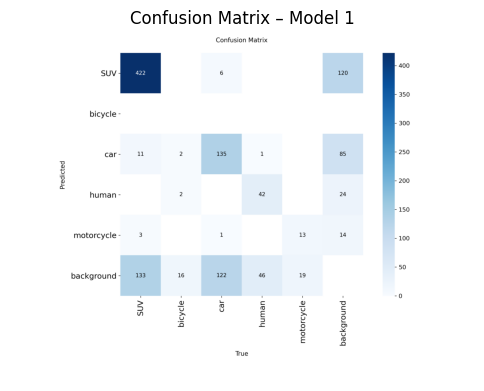

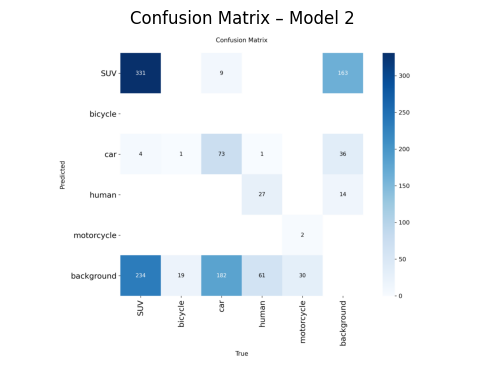

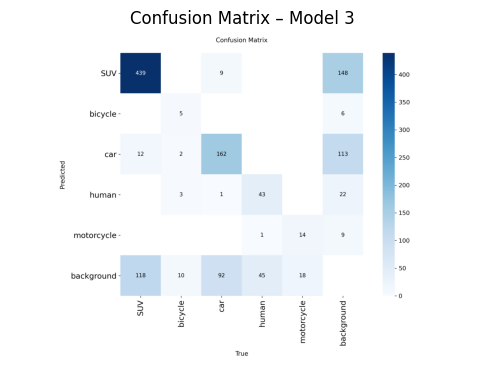

In [ ]:
# Import necessary libraries to open and display the confusion matrix images (Python Machine Learning - Confusion Matrix, 2026)
from PIL import Image
import matplotlib.pyplot as plt

# Define file paths of the confusion matrices for the three trained YOLO models (Python Machine Learning - Confusion Matrix, 2026)

paths = [
    "/content/runs/detect/yolo26_model1_adamw/confusion_matrix.png",
    "/content/runs/detect/yolo26_model2_sgd/confusion_matrix.png",
    "/content/runs/detect/yolo26_model3_auto/confusion_matrix.png"
]

# Loop through each image path and display the corresponding confusion matrix with a title (Python Machine Learning - Confusion Matrix, 2026)
for i, path in enumerate(paths, 1):
    img = Image.open(path)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Confusion Matrix – Model {i}")
    plt.show()

In [ ]:
# Store the evaluation results (e.g., mAP, precision, recall) for performance analysis
# Run validation on Model 1 using the validation dataset defined in data.yaml (Articles, 2026)
metrics1 = model1.val()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 20.4±4.6 MB/s, size: 33.5 KB)
val: Scanning /content/drive/MyDrive/traffic_dataset/valid/labels.cache... 93 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 93/93 39.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 638, len(boxes) = 974. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.1it/s 2.8s
                   all         93        974       0.72      0.401      0.457      0.261
                   SUV         93        569      0.808      0.722      0.776      0.516
               bicycle      

In [ ]:
# Run validation on Model 2 to evaluate its performance on the validation dataset
# Save the computed evaluation metrics (e.g., mAP, precision, recall) for comparison with other models (Articles, 2026)
metrics2 = model2.val()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 22.7±4.8 MB/s, size: 33.9 KB)
val: Scanning /content/drive/MyDrive/traffic_dataset/valid/labels.cache... 93 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 93/93 32.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 638, len(boxes) = 974. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.4it/s 2.5s
                   all         93        974      0.584      0.353      0.347      0.197
                   SUV         93        569      0.572       0.67      0.652      0.417
               bicycle      

In [ ]:
# Run validation on Model 3 using the validation set specified in data.yaml
# Store the validation metrics (e.g., mAP, precision, recall) for final performance comparison (Articles, 2026)
metrics3 = model3.val()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 16.6±2.6 MB/s, size: 35.5 KB)
val: Scanning /content/drive/MyDrive/traffic_dataset/valid/labels.cache... 93 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 93/93 21.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 638, len(boxes) = 974. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.3it/s 2.6s
                   all         93        974      0.658      0.507       0.55      0.332
                   SUV         93        569      0.751       0.76      0.791      0.546
               bicycle      

In [ ]:
# This dictionary can be used to create a summary table or DataFrame for easier comparison of model performance
# Compile key training and validation results from all three YOLO models into a single dictionary (Sitanand, 2025)

results = {
    "Model": ["Model 1 (AdamW)", "Model 2 (SGD)", "Model 3 (Auto)"],
    "Optimizer": ["AdamW", "SGD", "Auto"],
    "Epochs": [25, 30, 40],
    "Batch Size": [4, 20, "Auto"],
    "Learning Rate": [0.01, 0.001, 0.0001],
    "Precision": [
        metrics1.box.mp,
        metrics2.box.mp,
        metrics3.box.mp
    ],
    "Recall": [
        metrics1.box.mr,
        metrics2.box.mr,
        metrics3.box.mr
    ],
    "mAP50": [
        metrics1.box.map50,
        metrics2.box.map50,
        metrics3.box.map50
    ],
    "mAP50-95": [
        metrics1.box.map,
        metrics2.box.map,
        metrics3.box.map
    ]
}

# Convert the results dictionary into a pandas DataFrame for easier visualization and analysis (Vaibhav Jayaswal, 2020)

df_results = pd.DataFrame(results)


# Calculate the F1 Score for each model using the formula: 2 * (Precision * Recall) / (Precision + Recall) (Vaibhav Jayaswal, 2020)

df_results["F1 Score"] = 2 * (
    df_results["Precision"] * df_results["Recall"]
) / (
    df_results["Precision"] + df_results["Recall"]
)

# Display the final DataFrame showing all metrics including F1 Score (Vaibhav Jayaswal, 2020)

df_results

,Model,Optimizer,Epochs,Batch Size,Learning Rate,Precision,Recall,mAP50,mAP50-95,F1 Score
0,Model 1 (AdamW),AdamW,25,4,0.0100,0.720244,0.400966,0.457271,0.261084,0.515146
1,Model 2 (SGD),SGD,30,20,0.0010,0.584293,0.352507,0.347080,0.197092,0.439726
2,Model 3 (Auto),Auto,40,Auto,0.0001,0.658250,0.507168,0.550214,0.331572,0.572916


In [ ]:
# Create a separate DataFrame to summarize the training hyperparameters of each YOLO model
params = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "Optimizer": ["AdamW", "SGD", "Auto"],
    "Epochs": [25, 30, 40],
    "Batch Size": [4, 20, "Auto"],
    "Learning Rate": [0.01, 0.001, 0.0001]
})

# Display the hyperparameters table for easy reference and comparison (Sandipan Dey, 2023)
params

,Model,Optimizer,Epochs,Batch Size,Learning Rate
0,Model 1,AdamW,25,4,0.0100
1,Model 2,SGD,30,20,0.0010
2,Model 3,Auto,40,Auto,0.0001


# REFERENCES:

Scitator. (2018, January 22). How to read data in Google Colab from my Google drive? Stack Overflow. https://stackoverflow.com/questions/48376580/how-to-read-data-in-google-colab-from-my-google-drive

‌tate, sasha. (2024, August 21). when I was trying to import yolo from ultralytics. Stack Overflow. https://stackoverflow.com/questions/78895164/when-i-was-trying-to-import-yolo-from-ultralytics

‌Rai, L. (2019, January 24). accessing “Shared with me” with Colab. Stack Overflow. https://stackoverflow.com/questions/54351852/accessing-shared-with-me-with-colab

‌Train - Ultralytics YOLOv8 Docs. (2026). Docs.ultralytics.com. https://docs.ultralytics.com/modes/train/

‌Python Machine Learning - Confusion Matrix. (2026). Www.w3schools.com. https://www.w3schools.com/python/python_ml_confusion_matrix.asp

‌Articles. (2026). Docs.indicodata.ai. https://docs.indicodata.ai/articles/#

‌Vaibhav Jayaswal. (2020, September 14). Performance Metrics: Confusion matrix, Precision, Recall, and F1 Score | Towards Data Science. Towards Data Science. https://towardsdatascience.com/performance-metrics-confusion-matrix-precision-recall-and-f1-score-a8fe076a2262/

‌Sandipan Dey. (2023, December 6). Sandipanweb. https://sandipanweb.wordpress.com/author/sandipandey/

‌